In [2]:
using Pkg
Pkg.activate("../.")
using ValueFunctionIterations
using LaTeXStrings
Pkg.status("ValueFunctionIterations")
include("analysis/coverage.jl")

Status `~/github/FisheriesInsuranceModel/Project.toml`
  [dc40bd75] ValueFunctionIterations v0.7.7 `https://github.com/Jack-H-Buckner/ValueFunctionIterations.jl.git#master`


  Activating project at `~/github/FisheriesInsuranceModel`


plot_coverage_by_budget

(5, 300)

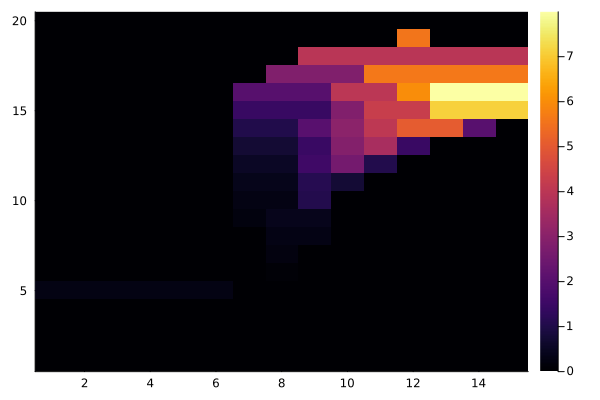

In [52]:
function coverage_levels(prob)
    # non bankrupt states only; the bankrupt branch carries a degenerate grid
    states = prob.V.states[:, prob.V.states[1, :] .== 1]
    states = states[:, states[5,:] .== 1.0]
    states = states[:, states[4,:] .== 0.0]
    print(size(states))

    # RegularGridBspline stores the axis ranges in `grid` and their lengths in
    # `dims` (see ValueFunctions.jl); `dims` is what reshape needs.
    bspline = prob.V.Bslines[1]
    dims = (20,15,1,1)#bspline.dims
    grid = bspline.grid

    u_opt = ValueFunctionIterations.policy(states, prob.u, prob.X, prob.R,
                                           prob.F, prob.p, prob.δ, prob.V)
    η_s = reshape(u_opt[2, :], dims...)
    η̄_s = mapslices(s -> price_per_exposure(El(s, prob.p), prob.p.cf, prob.p.cv),
                    states, dims = 1)
    η̄_s = reshape(η̄_s, dims...)

    return (η = η_s, η̄ = η̄_s, coverage = η_s ./ η̄_s, grid = grid)
end

problem = rebuild_problem("RA_int_pr50_re50")
cov_pr50 = coverage_levels(problem.prob)
η_s_50, η̄_s_50, state_grid = cov_pr50
p1 = Plots.heatmap(η_s[:,:,1,1]./η̄_s[:,:,1,1])
p1

(5, 300)

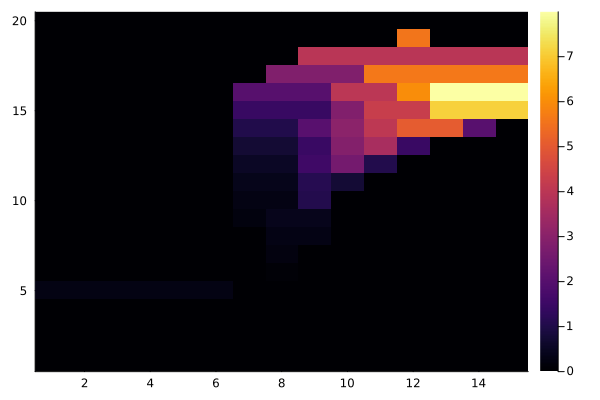

In [51]:
problem = rebuild_problem("RA_int_pr100_re100")
cov_pr100 = coverage_levels(problem.prob)
η_s_100, η̄_s_100, state_grid = cov_pr100
p1 = Plots.heatmap(η_s[:,:,1,1]./η̄_s[:,:,1,1])
p1

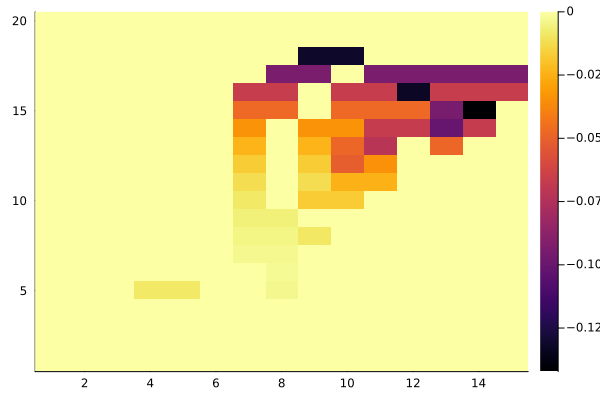

In [54]:
Plots.heatmap((η_s_50 .- η_s_100)[:,:,1,1])

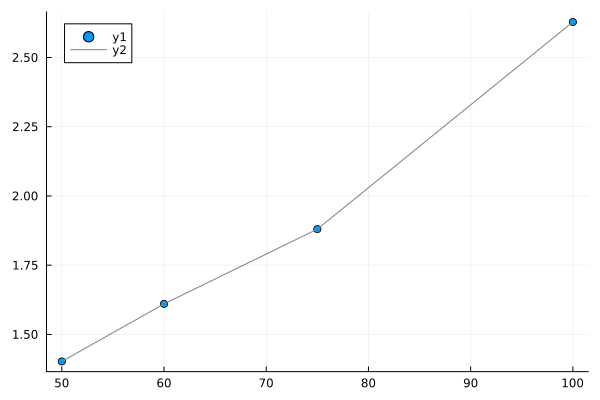

In [63]:
scenarios = ["RA_int_pr100_re100","RA_int_pr75_re100",
            "RA_int_pr60_re100","RA_int_pr50_re100"]
pr = [100,75,60,50]
coverage_re = zeros(4)
premium_re = zeros(4)
i = 0
sim_states = stationary_states(problem.prob.p, problem.Xmc; burnin = 500)
for sc in scenarios
    i +=1
    problem = rebuild_problem(sc)
    sol = coverage_by_budget(problem.prob, sim_states, [1.0] ;nmax = 250)[1]
    coverage_re[i] = sol.mean_coverage
    premium_re[i] = sol.mean_premium 
end 

Plots.scatter(pr,coverage)
Plots.plot!(pr,coverage, color = "grey")

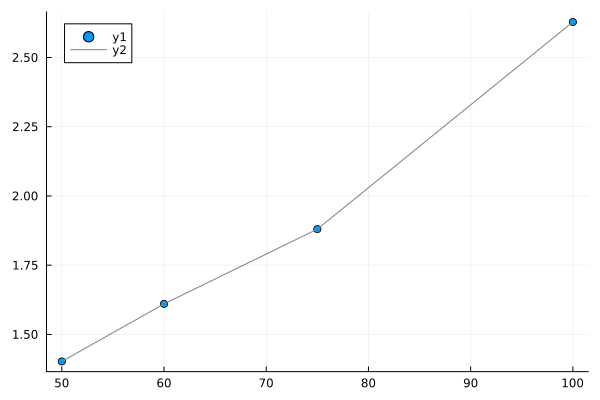

In [62]:

scenarios = ["RA_int_pr100_re100","RA_int_pr75_re75",
            "RA_int_pr60_re60","RA_int_pr50_re50"]
pr = [100,75,60,50]
coverage = zeros(4)
premium = zeros(4)
i = 0
sim_states = stationary_states(problem.prob.p, problem.Xmc; burnin = 500)
for sc in scenarios
    i +=1
    problem = rebuild_problem(sc)
    sol = coverage_by_budget(problem.prob, sim_states, [1.0] ;nmax = 250)[1]
    coverage[i] = sol.mean_coverage
    premium[i] = sol.mean_premium 
end 

Plots.scatter(pr,coverage)
Plots.plot!(pr,coverage, color = "grey")

In [69]:
include("analysis/value_diffs.jl")
value_diff_100 = value_diff_by_budget("RA_int_pr100_re100"; n_sim = 2000,budgets = [1.0])[1]
value_diff_50 = value_diff_by_budget("RA_int_pr50_re100"; n_sim = 2000,budgets = [1.0])[1]

(budget = 1.0, savings = -1.0, mean_value_ins = 14.787827515959044, mean_value_no = 14.237032552143331, mean_value_diff = 0.5507949638157121, q10_value_diff = 0.4898430297551622, q90_value_diff = 0.5773885225429923, mean_ce_ins = 2.1122754129291565, mean_ce_no = 2.0547788411253203, pct_increase_CE = 2.798187846452015, pct_increase_consumption = 2.7953507999721015, frac_better = 1.0, n_states = 2000)